In [18]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import torch
# from torch import nn
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier, RandomForestClassifier
import matplotlib.pyplot as plt
!pip install joblib
import joblib


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Loading

In [20]:
path=Path('../../data/insider_threat_clean_dataset.csv')
df_raw = pd.read_csv(path)

## Preprocessing

In [3]:
df_raw=df_raw.drop_duplicates()
df_raw = df_raw.dropna()

## Feature Engineering

In [4]:
df_raw=df_raw.drop(columns=['employee_campus','has_medical_history','employee_origin_country','has_foreign_citizenship','is_contractor'])

In [5]:
df_encoded = pd.get_dummies(df_raw,columns=['employee_department','employee_position'],prefix='categ')

In [6]:
feature_trn,feature_tst,label_trn,label_tst = sk.model_selection.train_test_split(df_encoded.drop(columns=['is_malicious']),df_encoded.is_malicious,train_size=0.75,random_state=113)

In [7]:
forest = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',random_state=113) #created a random forest object that would be used for trianing with pre paramters like the seed value of 113 aswell as the weight class and the total depth of the tree
forest.fit(feature_trn,label_trn) #the training sequence initiated
forest_pred = forest.predict(feature_tst) #the predicted values are generated and they are evaluated after they are calculated

In [8]:
print("\n--- Classification Report ---")
print(sk.metrics.classification_report(label_tst, forest_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     28046
           1       0.57      0.78      0.66      1608

    accuracy                           0.96     29654
   macro avg       0.78      0.88      0.82     29654
weighted avg       0.96      0.96      0.96     29654



In [9]:
print("--- Confusion Matrix ---")
print(sk.metrics.confusion_matrix(label_tst, forest_pred))

--- Confusion Matrix ---
[[27099   947]
 [  347  1261]]


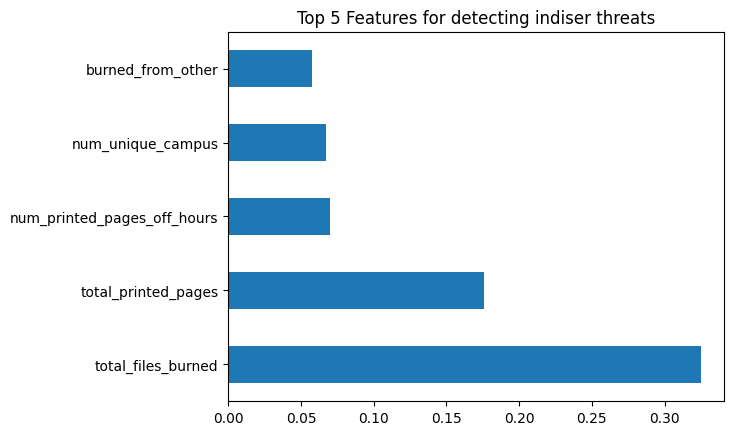

In [10]:
scores = pd.Series(forest.feature_importances_,index=df_encoded.drop(columns=['is_malicious']).columns)
scores.nlargest(5).plot(kind='barh')
plt.title("Top 5 Features for detecting indiser threats")
plt.show()

In [11]:
df_raw.is_malicious.explode().value_counts()

is_malicious
0    112228
1      6386
Name: count, dtype: int64

In [12]:
lst=list(df_raw.is_malicious.explode().value_counts())

In [13]:
(lst[1]/lst[0])*100

5.690202088605338

In [14]:
df_raw.head()

,employee_department,employee_position,employee_seniority_years,employee_classification,has_criminal_record,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Design Engineer,22,2,0,0,0,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Design Engineer,22,2,0,0,0,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Design Engineer,22,2,0,0,0,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Design Engineer,22,2,0,1,0,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Design Engineer,22,2,0,0,0,0,0,0,0.0,0,0,0,0,0,0


In [ ]:
path=Path('..\models')
model_file_path = path/'RForestModel.pkl'
joblib.dump(forest, model_file_path)

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\siphe\AppData\Local\Temp\ipykernel_13176\3882530697.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  path=Path('..\models')


['..\\models\\RForestModel.pkl']